<a href="https://colab.research.google.com/github/moratodpg/risk_reliability/blob/main/demos/r04_MonteCarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Default figure formatting
# ---------------------------------------------------------
FIG_WIDTH = 6.5       # inches
FIG_HEIGHT = 4.0      # inches
FONT_SIZE = 11

mpl.rcParams.update({
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),

    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE + 1,
    "xtick.labelsize": FONT_SIZE - 1,
    "ytick.labelsize": FONT_SIZE - 1,
    "legend.fontsize": FONT_SIZE - 1,

    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # Embed TrueType fonts in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Folder for separately saved illustrations
# FIGURE_DIR = Path("figures_04")
# FIGURE_DIR.mkdir(exist_ok=True)

## Quadrature

In [132]:
import numpy as np

rng = np.random.default_rng(seed=42)

N = 100_000

x = rng.uniform(-1, 1, size=N)
y = rng.uniform(-1, 1, size=N)

eval = x**2 + y**2 

inside = eval <= 1

pi_estimate = 4 * np.mean(inside)

print(f"Estimated π: {pi_estimate:.6f}")
print(f"True π:      {np.pi:.6f}")
print(f"Error:       {pi_estimate - np.pi:.6f}")

Estimated π: 3.143080
True π:      3.141593
Error:       0.001487


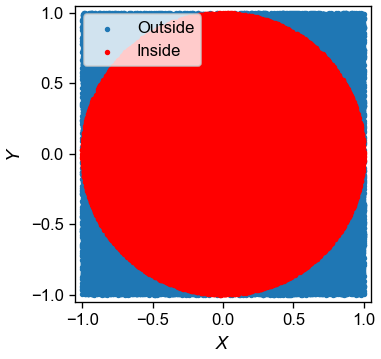

In [133]:
N_plot = 100_000 # 20, 5_000, 100_000

x_plot = x[:N_plot]
y_plot = y[:N_plot]
inside_plot = inside[:N_plot]

fig, ax = plt.subplots(figsize=(3.2, 3.2))

ax.scatter(
    x_plot[~inside_plot],
    y_plot[~inside_plot],
    s=5,
    color="tab:blue",
    label="Outside",
)

ax.scatter(
    x_plot[inside_plot],
    y_plot[inside_plot],
    s=5,
    color="red",
    label="Inside",
)

ax.set(
    xlabel="$X$",
    ylabel="$Y$",
    xlim=(-1.05, 1.05),
    ylim=(-1.05, 1.05),
    aspect="equal",
)

ax.legend()
# fig.savefig(FIGURE_DIR / "pi_monte_carlo_4.pdf")
plt.show()

## Random number generation

In [134]:
import numpy as np

rng = np.random.default_rng(seed=42)

uniform_samples = rng.random(5)           # Uniform on [0, 1)

normal_samples = rng.normal(0, 1, size=5)  # Standard normal
poisson_samples = rng.poisson(4.125, size=5)

print("Uniform samples:", uniform_samples)
print("Normal samples:", normal_samples)
print("Poisson samples:", poisson_samples)

Uniform samples: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
Normal samples: [-1.30217951  0.1278404  -0.31624259 -0.01680116 -0.85304393]
Poisson samples: [6 4 5 5 2]


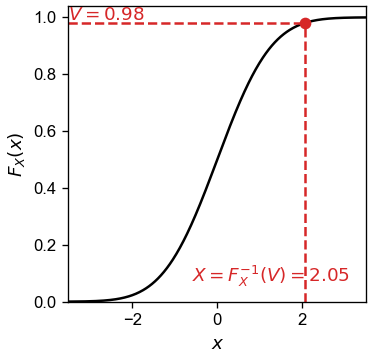

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

v = 0.98
x_v = norm.ppf(v)

x = np.linspace(-3.5, 3.5, 500)

fig, ax = plt.subplots(figsize=(3.2, 3.2))

ax.plot(x, norm.cdf(x), color="black")
ax.plot([x.min(), x_v], [v, v], "--", color="tab:red")
ax.plot([x_v, x_v], [0, v], "--", color="tab:red")
ax.plot(x_v, v, "o", color="tab:red")

ax.text(x.min(), v + 0.010, r"$V=0.98$", color="tab:red")
ax.text(x_v-0.8, 0.07, rf"$X=F_X^{{-1}}(V)={x_v:.2f}$",
        color="tab:red", ha="center")

ax.set(xlabel="$x$", ylabel="$F_X(x)$",
       xlim=(x.min(), x.max()), ylim=(0, 1.04))

# fig.savefig(FIGURE_DIR / "inverse_CDF.pdf")
plt.show()

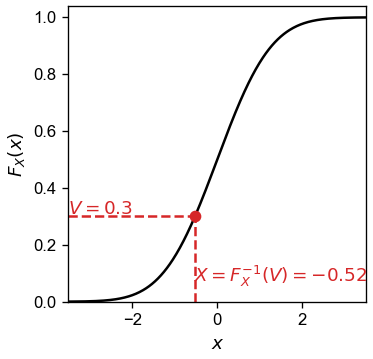

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

v = 0.3
x_v = norm.ppf(v)

x = np.linspace(-3.5, 3.5, 500)

fig, ax = plt.subplots(figsize=(3.2, 3.2))

ax.plot(x, norm.cdf(x), color="black")
ax.plot([x.min(), x_v], [v, v], "--", color="tab:red")
ax.plot([x_v, x_v], [0, v], "--", color="tab:red")
ax.plot(x_v, v, "o", color="tab:red")

ax.text(x.min(), v + 0.010, r"$V=0.3$", color="tab:red")
ax.text(1.5, 0.07, rf"$X=F_X^{{-1}}(V)={x_v:.2f}$",
        color="tab:red", ha="center")

ax.set(xlabel="$x$", ylabel="$F_X(x)$",
       xlim=(x.min(), x.max()), ylim=(0, 1.04))

# fig.savefig(FIGURE_DIR / "inverse_CDF_2.pdf")
plt.show()

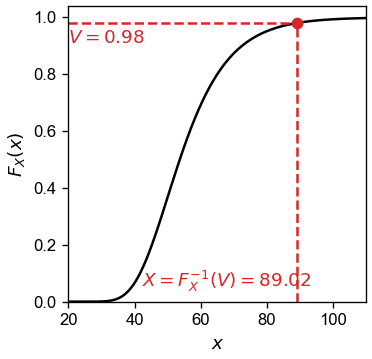

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r

a, b = 50, 10                 # location and scale
v = 0.98
x_v = a - b*np.log(-np.log(v))

x = np.linspace(20, 110, 500)

fig, ax = plt.subplots(figsize=(3.2, 3.2))

ax.plot(x, gumbel_r.cdf(x, loc=a, scale=b), color="black")
ax.plot([x.min(), x_v], [v, v], "--", color="tab:red")
ax.plot([x_v, x_v], [0, v], "--", color="tab:red")
ax.plot(x_v, v, "o", color="tab:red")

ax.text(x.min(), v - 0.07, r"$V=0.98$", color="tab:red")
ax.text(68, 0.05, rf"$X=F_X^{{-1}}(V)={x_v:.2f}$",
        color="tab:red", ha="center")

ax.set(xlabel="$x$", ylabel="$F_X(x)$",
       xlim=(x.min(), x.max()), ylim=(0, 1.04))

# fig.savefig(FIGURE_DIR / "inverse_CDF_gumbel_1.pdf")
plt.show()

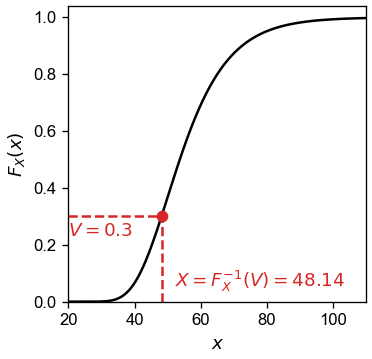

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r

a, b = 50, 10                 # location and scale
v = 0.3
x_v = a - b*np.log(-np.log(v))

x = np.linspace(20, 110, 500)

fig, ax = plt.subplots(figsize=(3.2, 3.2))

ax.plot(x, gumbel_r.cdf(x, loc=a, scale=b), color="black")
ax.plot([x.min(), x_v], [v, v], "--", color="tab:red")
ax.plot([x_v, x_v], [0, v], "--", color="tab:red")
ax.plot(x_v, v, "o", color="tab:red")

ax.text(x.min(), v - 0.07, r"$V=0.3$", color="tab:red")
ax.text(78, 0.05, rf"$X=F_X^{{-1}}(V)={x_v:.2f}$",
        color="tab:red", ha="center")

ax.set(xlabel="$x$", ylabel="$F_X(x)$",
       xlim=(x.min(), x.max()), ylim=(0, 1.04))

# fig.savefig(FIGURE_DIR / "inverse_CDF_gumbel_2.pdf")
plt.show()

In [58]:
# generate random samples from the Gumbel distribution

number_of_samples = 100
scale = 10
loc = 50

samples_gumbel = gumbel_r.rvs(loc=loc, scale=scale, size=number_of_samples)

# compute mean and standard deviation of the samples
mean_samples = np.mean(samples_gumbel)
std_samples = np.std(samples_gumbel)

print(f"Mean of samples: {mean_samples:.2f}")
print(f"Standard deviation of samples: {std_samples:.2f}")

Mean of samples: 54.81
Standard deviation of samples: 11.27


For a Gumbel distribution with location $a$ and scale $b$:

$$ \mathbb{E}[X]=a+\gamma b, \qquad \operatorname{SD}[X]=\frac{\pi}{\sqrt{6}}b, $$

where $\gamma \approx 0.5772 $ is the Euler–Mascheroni constant. Rearranging:

$$ \boxed{\hat b=\frac{\sqrt{6}}{\pi}s} $$

and

$$ \boxed{\hat a=\bar{x}-\gamma\hat b}. $$

In [59]:
# Method-of-moments estimates
gamma = 0.5772156649
scale_estimate = std_samples * np.sqrt(6) / np.pi
loc_estimate = mean_samples - gamma * scale_estimate

print(f"Estimated location: {loc_estimate:.2f}")
print(f"Estimated scale:    {scale_estimate:.2f}")

Estimated location: 49.74
Estimated scale:    8.79


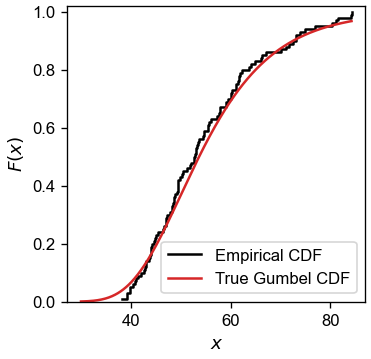

In [ ]:
# Empirical CDF
x = np.sort(samples_gumbel)
F_empirical = np.arange(1, number_of_samples + 1) / number_of_samples

# fig, ax = plt.subplots(figsize=(6, 4))

# ax.step(x, F_empirical, where="post", color="black")

# ax.set(
#     xlabel="$x$",
#     ylabel="$F_n(x)$",
#     ylim=(0, 1.02)
# )

x_grid = np.linspace(30, x.max(), 500)

fig, ax = plt.subplots(figsize=(3.2, 3.2))

ax.step(x, F_empirical, where="post",
        color="black", label="Empirical CDF")

ax.plot(x_grid, gumbel_r.cdf(x_grid, loc=loc, scale=scale),
        color="tab:red", label="True Gumbel CDF")

ax.set(
    xlabel="$x$",
    ylabel="$F(x)$",
    ylim=(0, 1.02)
)

ax.legend()

# fig.savefig(FIGURE_DIR / "gumbel_empirical_CDF.pdf")
plt.show()

## Example: Load and resistance

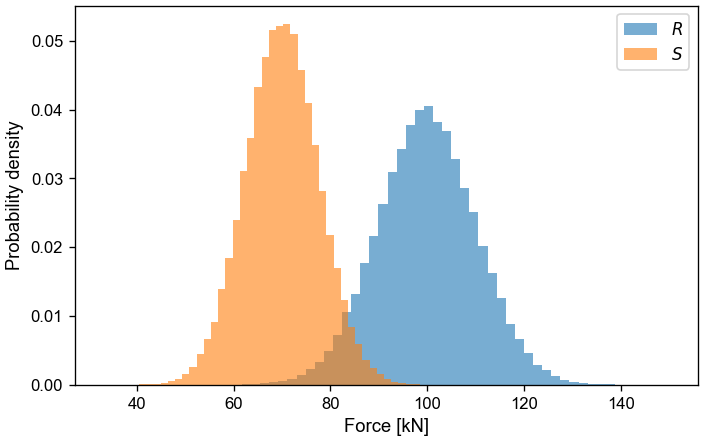

Mean of R: 99.96, Std of R: 10.04
Mean of S: 70.02, Std of S: 7.51


In [ ]:
# (1) Generate random samples

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

N = 100_000
rng = np.random.default_rng(42)

R = rng.normal(100, 10, N)
S = rng.normal(70, 7.5, N)

fig, ax = plt.subplots(figsize=(6.7, 4.1))

ax.hist(R, bins=50, density=True, alpha=0.6, label="$R$")
ax.hist(S, bins=50, density=True, alpha=0.6, label="$S$")

ax.set(xlabel="Force [kN]", ylabel="Probability density")
ax.legend()

# fig.savefig(FIGURE_DIR / "histograms_R_S.pdf")
plt.show()

# compute mean and standard deviation of the samples
mean_R = np.mean(R)
std_R = np.std(R)
mean_S = np.mean(S)
std_S = np.std(S)

print(f"Mean of R: {mean_R:.2f}, Std of R: {std_R:.2f}")
print(f"Mean of S: {mean_S:.2f}, Std of S: {std_S:.2f}")

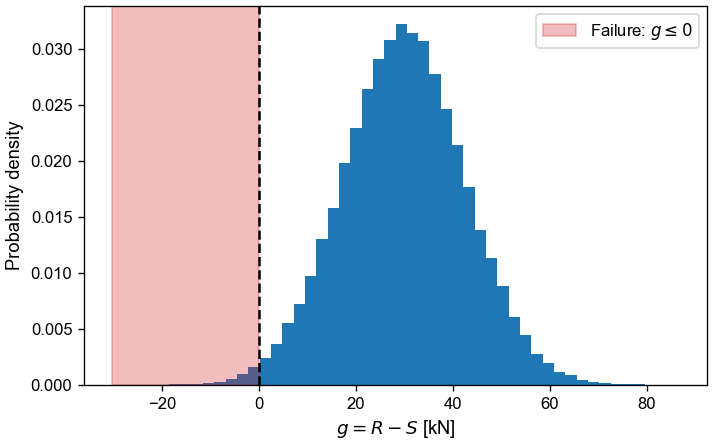

In [ ]:
g = R - S

fig, ax = plt.subplots(figsize=(6.7, 4.1))

ax.hist(g, bins=50, density=True, color="tab:blue")
ax.axvspan(g.min(), 0, color="tab:red", alpha=0.3,
           label="Failure: $g \leq 0$")
ax.axvline(0, color="black", linestyle="--")

ax.set(xlabel="$g=R-S$ [kN]", ylabel="Probability density")
ax.legend()

# fig.savefig(FIGURE_DIR / "histogram_g.pdf")
plt.show()

In [101]:
failure = g <= 0

number_of_failures = np.sum(failure)
pf = np.mean(failure)
beta = -norm.ppf(pf)

print(f"Number of failures: {number_of_failures}")
print(f"Estimated failure probability: {pf:.5f}")
print(f"Reliability index: {beta:.3f}")

Number of failures: 821
Estimated failure probability: 0.00821
Reliability index: 2.399


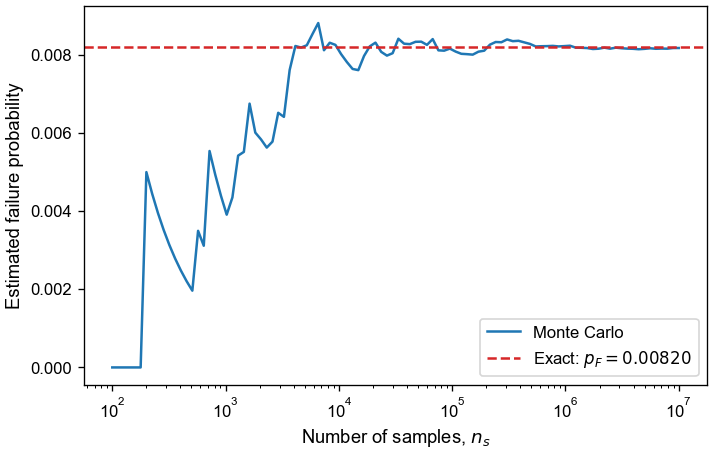

In [ ]:
N_conv = 10_000_000

R_conv = rng.normal(100, 10, N_conv)
S_conv = rng.normal(70, 7.5, N_conv)
failure_conv = R_conv - S_conv <= 0

sample_sizes = np.unique(
    np.logspace(2, np.log10(N_conv), 100).astype(int)
)

cumulative_failures = np.cumsum(failure_conv)
pf_convergence = cumulative_failures[sample_sizes - 1] / sample_sizes

pf_exact = norm.cdf(-30 / 12.5)

fig, ax = plt.subplots(figsize=(6.7, 4.1))

ax.plot(sample_sizes, pf_convergence, label="Monte Carlo")
ax.axhline(pf_exact, color="tab:red", linestyle="--",
           label=rf"Exact: $p_F={pf_exact:.5f}$")

ax.set_xscale("log")
ax.set(xlabel="Number of samples, $n_s$",
       ylabel="Estimated failure probability")
ax.legend()


# fig.savefig(FIGURE_DIR / "convergence_pf.pdf")
plt.show()

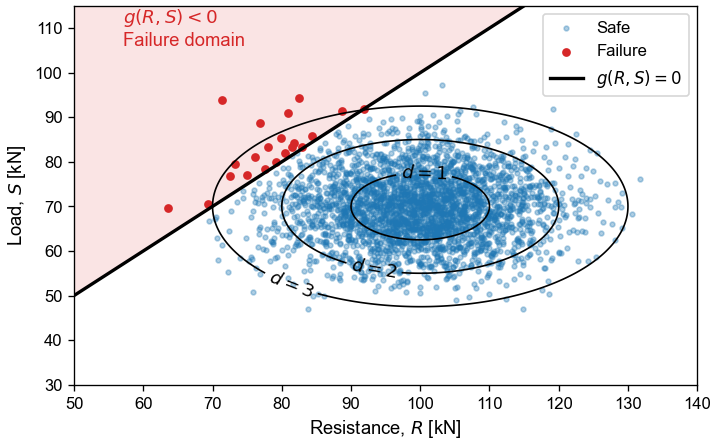

In [ ]:
# Plot only a subset of the Monte Carlo samples
n_plot = 3000
R_plot = R[:n_plot]
S_plot = S[:n_plot]
failure_plot = R_plot - S_plot <= 0

# Grid for the level curves
r = np.linspace(50, 140, 300)
s = np.linspace(30, 115, 300)
RR, SS = np.meshgrid(r, s)

# Standardized distance from the mean
distance = np.sqrt(
    ((RR - 100) / 10)**2 +
    ((SS - 70) / 7.5)**2
)

fig, ax = plt.subplots(figsize=(6.7, 4.1))

# Failure domain: S > R
ax.contourf(
    RR, SS, RR - SS,
    levels=[-1000, 0],
    colors=["tab:red"],
    alpha=0.12
)

# Joint-density level curves
contours = ax.contour(
    RR, SS, distance,
    levels=[1, 2, 3],
    colors="black",
    linewidths=1
)
ax.clabel(contours, fmt={1: "$d=1$", 2: "$d=2$", 3: "$d=3$"})

# Monte Carlo samples
ax.scatter(R_plot[~failure_plot], S_plot[~failure_plot],
           s=8, alpha=0.35, label="Safe")

ax.scatter(R_plot[failure_plot], S_plot[failure_plot],
           s=18, color="tab:red", label="Failure")

# Limit-state boundary: R - S = 0
ax.plot(r, r, color="black", linewidth=2,
        label="$g(R,S)=0$")

ax.text(57, 106, "$g(R,S)<0$\nFailure domain",
        color="tab:red")

ax.set(
    xlabel="Resistance, $R$ [kN]",
    ylabel="Load, $S$ [kN]",
    xlim=(50, 140),
    ylim=(30, 115)
)

ax.legend()
# fig.savefig(FIGURE_DIR / "reliability_domain.pdf")
plt.show()

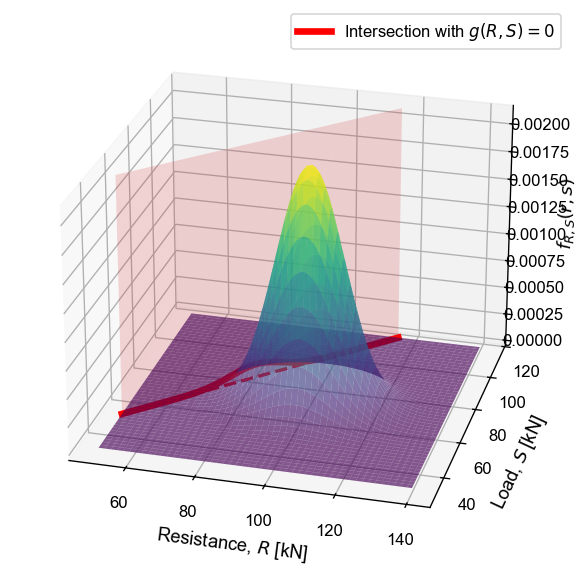

In [ ]:
# Joint PDF
r = np.linspace(50, 140, 200)
s = np.linspace(30, 115, 200)
RR, SS = np.meshgrid(r, s)

pdf = (
    norm.pdf(RR, loc=100, scale=10) *
    norm.pdf(SS, loc=70, scale=7.5)
)

fig = plt.figure(figsize=(7.7, 6.1))
ax = fig.add_subplot(111, projection="3d")

# PDF mountain
ax.plot_surface(
    RR, SS, pdf,
    cmap="viridis",
    edgecolor="none",
    alpha=0.65
)

# Vertical limit-state plane: S = R
boundary = np.linspace(50, 115, 200)
B, Z_plane = np.meshgrid(
    boundary,
    np.linspace(0, pdf.max(), 40)
)

ax.plot_surface(
    B, B, Z_plane,
    color="tab:red",
    alpha=0.18,
    shade=False
)

# Intersection between the plane and the PDF surface
pdf_boundary = (
    norm.pdf(boundary, loc=100, scale=10) *
    norm.pdf(boundary, loc=70, scale=7.5)
)

ax.plot(
    boundary, boundary, pdf_boundary,
    color="red",
    linewidth=4,
    label="Intersection with $g(R,S)=0$"
)

# Projection of the boundary onto the base
ax.plot(
    boundary, boundary, np.zeros_like(boundary),
    color="red",
    linestyle="--",
    linewidth=2
)

ax.set(
    xlabel="Resistance, $R$ [kN]",
    ylabel="Load, $S$ [kN]",
    zlabel="$f_{R,S}(r,s)$"
)

ax.view_init(elev=25, azim=-75)
ax.legend()

# fig.savefig(FIGURE_DIR / "joint_pdf_3D_limit_state.pdf")
plt.show()

## Exercise: evacuation reliability

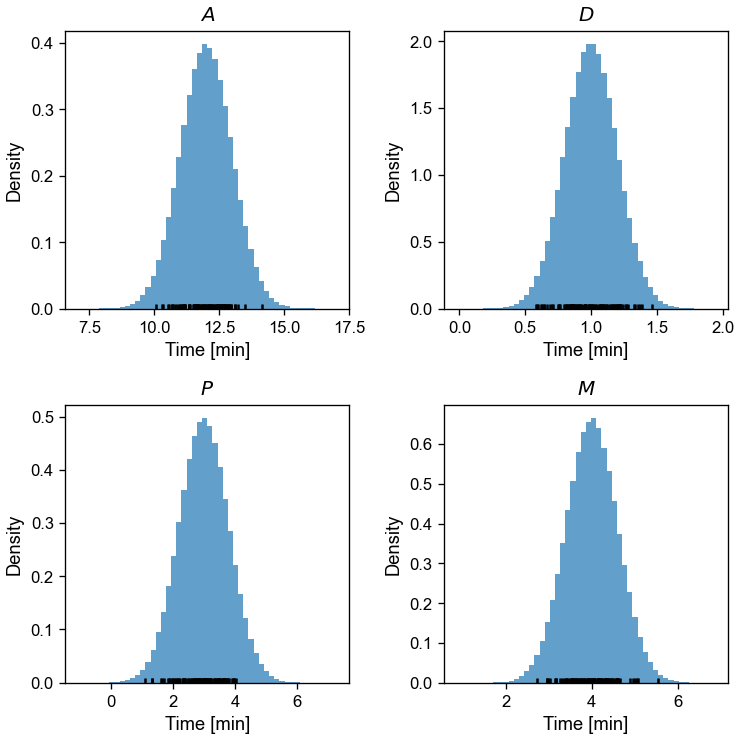

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

N = 1_000_000
rng = np.random.default_rng(42)

A = rng.normal(12.0, 1.0, N)
D = rng.normal(1.0, 0.2, N)
P = rng.normal(3.0, 0.8, N)
M = rng.normal(4.0, 0.6, N)

variables = {
    "$A$": A,
    "$D$": D,
    "$P$": P,
    "$M$": M
}

fig, axes = plt.subplots(2, 2, figsize=(3.2 * 2, 3.2 * 2))

for ax, (name, values) in zip(axes.flat, variables.items()):
    ax.hist(values, bins=50, density=True, alpha=0.7)
    ax.scatter(values[:100], np.zeros(100), marker="|", color="black")
    ax.set(title=name, xlabel="Time [min]", ylabel="Density")

fig.tight_layout()
# fig.savefig(FIGURE_DIR / "evac_input_variables.pdf")
plt.show()

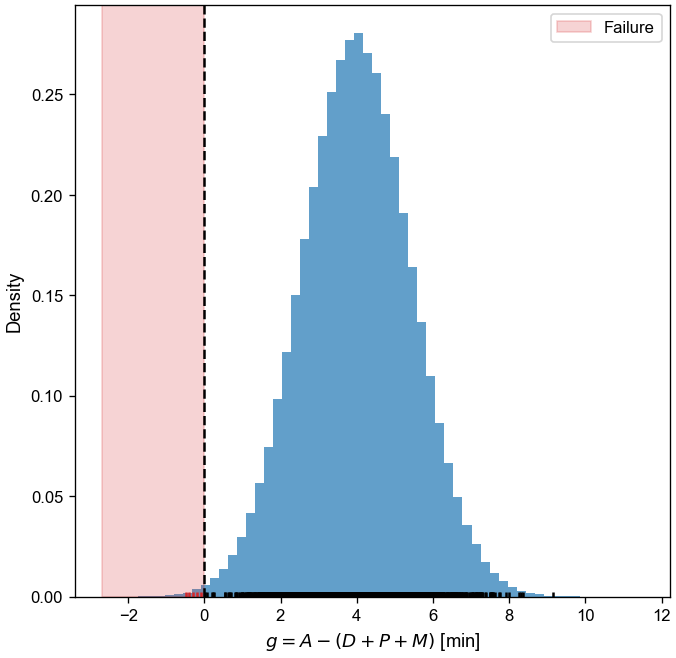

In [ ]:
total_time = D + P + M
g = A - total_time
failure = g <= 0

fig, ax = plt.subplots(figsize=(3.2*2, 3.2*2))

ax.hist(g, bins=60, density=True, alpha=0.7)

# Show a subset of the individual evaluations
n_markers = 2000
ax.scatter(
    g[:n_markers],
    np.zeros(n_markers),
    c=np.where(failure[:n_markers], "tab:red", "black"),
    marker="|"
)

ax.axvspan(g.min(), 0, color="tab:red", alpha=0.2,
           label="Failure")
ax.axvline(0, color="black", linestyle="--")

ax.set(
    xlabel="$g=A-(D+P+M)$ [min]",
    ylabel="Density"
)
ax.legend()

# fig.savefig(FIGURE_DIR / "evac_limit_state_evaluations.pdf")
plt.show()

In [96]:
number_of_failures = np.sum(failure)
pf = np.mean(failure)
# reliability index 
beta = -norm.ppf(pf)

print(f"Number of failures: {number_of_failures}")
print(f"Failure probability: {pf:.6f}")
print(f"Reliability index: {beta:.3f}")

Number of failures: 2530
Failure probability: 0.002530
Reliability index: 2.803


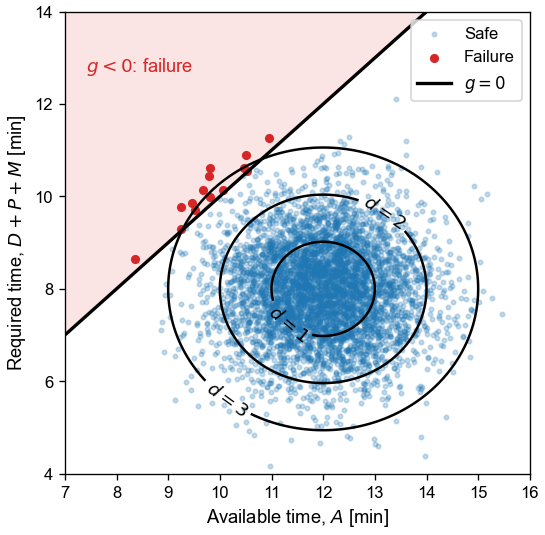

In [ ]:
mean_T = 1.0 + 3.0 + 4.0
std_T = np.sqrt(0.2**2 + 0.8**2 + 0.6**2)

a = np.linspace(7, 16, 300)
t = np.linspace(4, 14, 300)
AA, TT = np.meshgrid(a, t)

# Standardized distance from the joint mean
distance = np.sqrt(
    ((AA - 12.0) / 1.0)**2 +
    ((TT - mean_T) / std_T)**2
)

fig, ax = plt.subplots(figsize=(5, 5))

# Failure domain: T >= A
ax.contourf(
    AA, TT, AA - TT,
    levels=[-100, 0],
    colors=["tab:red"],
    alpha=0.12
)

# Joint-density level curves
contours = ax.contour(
    AA, TT, distance,
    levels=[1, 2, 3],
    colors="black"
)
ax.clabel(contours, fmt="$d=%1.0f$")

# Plot a subset of samples
n_plot = 5000

ax.scatter(
    A[:n_plot][~failure[:n_plot]],
    total_time[:n_plot][~failure[:n_plot]],
    s=7, alpha=0.25, label="Safe"
)

ax.scatter(
    A[:n_plot][failure[:n_plot]],
    total_time[:n_plot][failure[:n_plot]],
    s=20, color="tab:red", label="Failure"
)

# Limit-state boundary
ax.plot(a, a, color="black", linewidth=2,
        label="$g=0$")

ax.text(7.4, 12.7, "$g<0$: failure", color="tab:red")

ax.set(
    xlabel="Available time, $A$ [min]",
    ylabel="Required time, $D+P+M$ [min]",
    xlim=(7, 16),
    ylim=(4, 14)
)

ax.legend(loc="upper right", fontsize=10)
# fig.savefig(FIGURE_DIR / "evac_reliability_domain_evacuation.pdf")
plt.show()

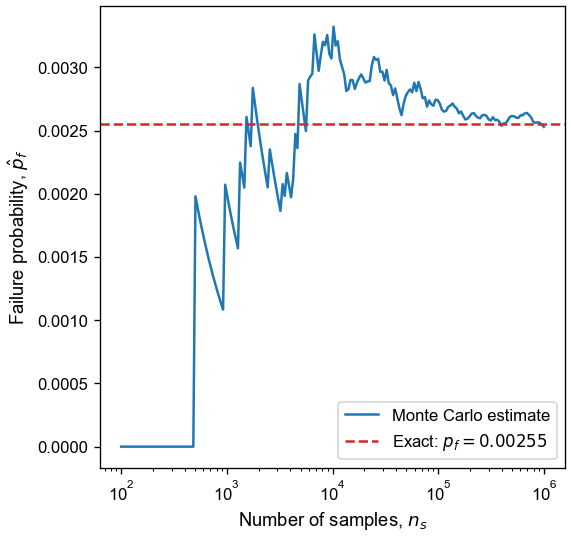

In [ ]:
sample_sizes = np.unique(
    np.logspace(2, np.log10(N), 200).astype(int)
)

cumulative_failures = np.cumsum(failure)

pf_convergence = (
    cumulative_failures[sample_sizes - 1] / sample_sizes
)

# Analytical reference solution
mean_g = 12 - (1 + 3 + 4)
std_g = np.sqrt(1**2 + 0.2**2 + 0.8**2 + 0.6**2)
pf_exact = norm.cdf(-mean_g / std_g)

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(sample_sizes, pf_convergence,
        label="Monte Carlo estimate")

ax.axhline(
    pf_exact,
    color="tab:red",
    linestyle="--",
    label=rf"Exact: $p_f={pf_exact:.5f}$"
)

ax.set_xscale("log")
ax.set(
    xlabel="Number of samples, $n_s$",
    ylabel="Failure probability, $\hat{p}_f$"
)

ax.legend()
# fig.savefig(FIGURE_DIR / "evac_convergence_evacuation.pdf")
plt.show()

## Example: evacuation reliability with computed movement time

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

N = 1_000_000
rng = np.random.default_rng(42)

# Original variables
A = rng.normal(12.0, 1.0, N)
D = rng.normal(1.0, 0.2, N)
P = rng.normal(3.0, 0.8, N)

# Inputs to the evacuation model
L = rng.normal(200, 20, N)                       # distance [m]
C = rng.uniform(0.5, 1.8, N)                     # crowd density [person/m²]

mean_V = 1.20
std_V = 0.15
sigma_ln = np.sqrt(np.log(1 + (std_V / mean_V)**2))
mu_ln = np.log(mean_V) - 0.5 * sigma_ln**2
V = rng.lognormal(mu_ln, sigma_ln, N)          # walking speed [m/s]

def evacuation_model(L, V, C):
    travel_time = L / (60 * V)
    congestion = 1 + 0.25 * C**2
    queue_delay = (
        0.15 * C**1.5
        + 0.8 * np.maximum(C - 1.2, 0)**2
    )
    return travel_time * congestion + queue_delay

M = evacuation_model(L, V, C)

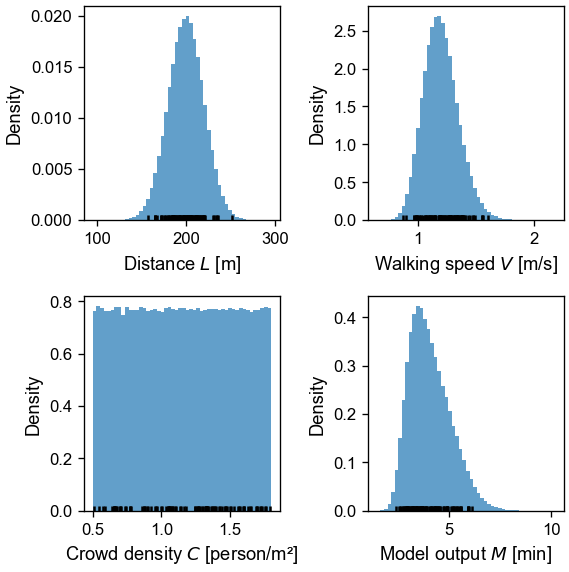

In [ ]:
variables = {
    "Distance $L$ [m]": L,
    "Walking speed $V$ [m/s]": V,
    "Crowd density $C$ [person/m²]": C,
    "Model output $M$ [min]": M
}

fig, axes = plt.subplots(2, 2, figsize=(5, 5))

for ax, (label, values) in zip(axes.flat, variables.items()):
    ax.hist(values, bins=50, density=True, alpha=0.7)
    ax.scatter(values[:100], np.zeros(100),
               marker="|", color="black")
    ax.set(xlabel=label, ylabel="Density")

fig.tight_layout()
# fig.savefig(FIGURE_DIR / "evac_detailed_input_variables_evacuation.pdf")
plt.show()

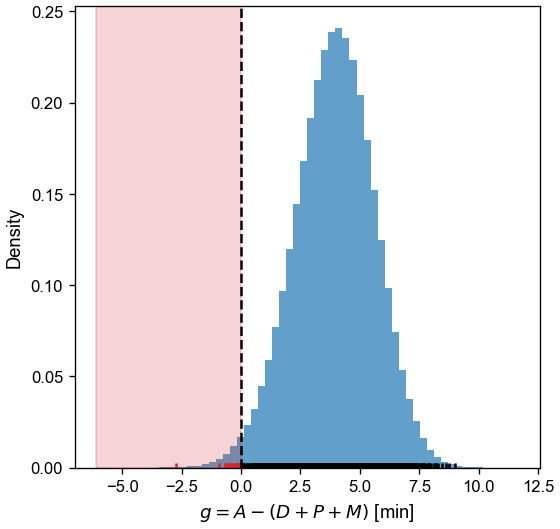

In [ ]:
total_time = D + P + M
g = A - total_time
failure = g <= 0

fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(g, bins=60, density=True, alpha=0.7)

n_markers = 2000
ax.scatter(
    g[:n_markers],
    np.zeros(n_markers),
    c=np.where(failure[:n_markers], "tab:red", "black"),
    marker="|"
)

ax.axvspan(g.min(), 0, color="tab:red", alpha=0.2)
ax.axvline(0, color="black", linestyle="--")

ax.set(
    xlabel="$g=A-(D+P+M)$ [min]",
    ylabel="Density"
)


# fig.savefig(FIGURE_DIR / "evac_detailed_black_box_limit_state.pdf")
plt.show()

In [107]:
pf = np.mean(failure)
beta = -norm.ppf(pf)

print(f"Number of failures: {np.sum(failure)}")
print(f"Failure probability: {pf:.6f}")
print(f"Reliability index: {beta:.3f}")

Number of failures: 12292
Failure probability: 0.012292
Reliability index: 2.248


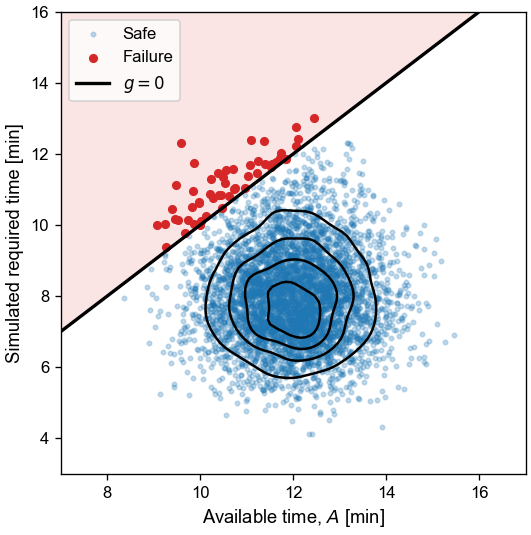

In [ ]:
# Use a subset to fit the density efficiently
n_kde = 5000
data = np.vstack((A[:n_kde], total_time[:n_kde]))
kde = gaussian_kde(data)

a_grid = np.linspace(7, 17, 100)
t_grid = np.linspace(3, 16, 100)
AA, TT = np.meshgrid(a_grid, t_grid)

density = kde(np.vstack((AA.ravel(), TT.ravel())))
density = density.reshape(AA.shape)

fig, ax = plt.subplots(figsize=(5, 5))

# Failure domain
ax.contourf(
    AA, TT, AA - TT,
    levels=[(AA - TT).min(), 0],
    colors=["tab:red"],
    alpha=0.12
)

# Sample-based density level curves
ax.contour(
    AA, TT, density,
    levels=5,
    colors="black"
)

# Monte Carlo samples
n_plot = 5000

ax.scatter(
    A[:n_plot][~failure[:n_plot]],
    total_time[:n_plot][~failure[:n_plot]],
    s=7, alpha=0.25, label="Safe"
)

ax.scatter(
    A[:n_plot][failure[:n_plot]],
    total_time[:n_plot][failure[:n_plot]],
    s=20, color="tab:red", label="Failure"
)

# Limit-state boundary
line = np.linspace(7, 16, 100)
ax.plot(line, line, color="black", linewidth=2,
        label="$g=0$")

ax.set(
    xlabel="Available time, $A$ [min]",
    ylabel="Simulated required time [min]",
    xlim=(7, 17),
    ylim=(3, 16)
)

ax.legend()
# fig.savefig(FIGURE_DIR / "evac_detailed_black_box_reliability_domain.pdf")
plt.show()

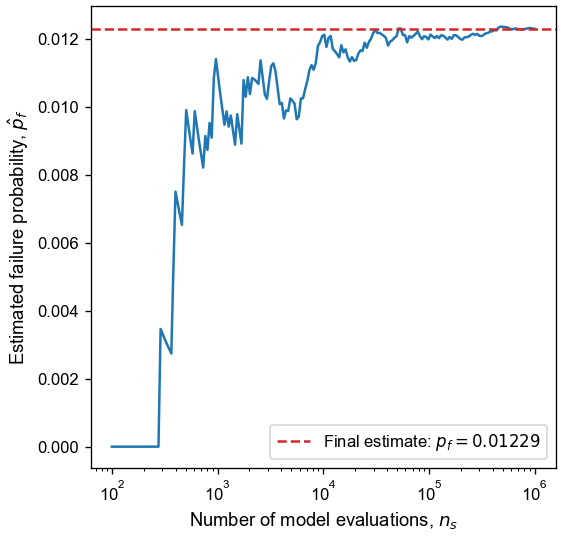

In [ ]:
sample_sizes = np.unique(
    np.logspace(2, np.log10(N), 200).astype(int)
)

cumulative_failures = np.cumsum(failure)
pf_convergence = cumulative_failures[sample_sizes - 1] / sample_sizes

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(sample_sizes, pf_convergence)
ax.axhline(pf, color="tab:red", linestyle="--",
           label=rf"Final estimate: $p_f={pf:.5f}$")

ax.set_xscale("log")
ax.set(
    xlabel="Number of model evaluations, $n_s$",
    ylabel="Estimated failure probability, $\hat{p}_f$"
)

ax.legend()
# fig.savefig(FIGURE_DIR / "evac_detailed_black_box_convergence.pdf")
plt.show()

## Uncertainty of the estimator

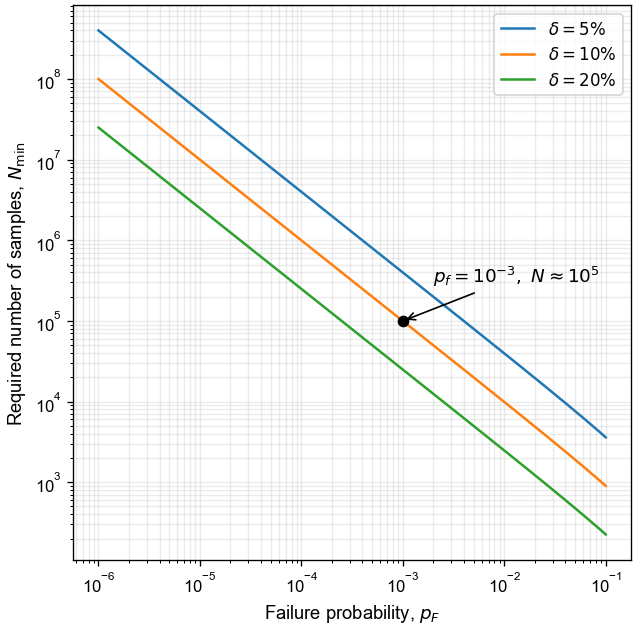

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

# Failure probabilities and target coefficients of variation
pf_values = np.logspace(-6, -1, 200)
deltas = [0.05, 0.10, 0.20]

fig, ax = plt.subplots(figsize=(6, 6))

for delta in deltas:
    N_min = (1 - pf_values) / (pf_values * delta**2)

    ax.loglog(
        pf_values,
        N_min,
        label=rf"$\delta={100 * delta:.0f}\%$"
    )

# Example: pf = 10^-3 and delta = 10%
pf_example = 1e-3
delta_example = 0.10

N_example = (
    (1 - pf_example) /
    (pf_example * delta_example**2)
)

ax.scatter(
    pf_example,
    N_example,
    color="black",
    zorder=3
)

ax.annotate(
    rf"$p_f=10^{{-3}},\ N\approx10^5$",
    xy=(pf_example, N_example),
    xytext=(2e-3, 3e5),
    arrowprops={"arrowstyle": "->"}
)

ax.set_xlabel("Failure probability, $p_F$")
ax.set_ylabel("Required number of samples, $N_{\min}$")

ax.grid(which="both", alpha=0.25)
ax.legend()

# fig.savefig(
#     # FIGURE_DIR / "required_MC_samples.pdf",
#     bbox_inches="tight"
# )

plt.show()